In [1]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/data")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: moubani
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data


100%|██████████| 84.7M/84.7M [00:00<00:00, 1.48GB/s]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Datasets import

In [3]:
df_city= pd.read_csv("/content/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv")
df_country= pd.read_csv("/content/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCountry.csv")
df_state= pd.read_csv("/content/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByState.csv")
df_majorcity= pd.read_csv("/content/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByMajorCity.csv")
df_temparatures= pd.read_csv("/content/climate-change-earth-surface-temperature-data/GlobalTemperatures.csv")

In [4]:
df_majorcity.sample(10)

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
150637,1903-10-01,27.010,0.815,Mogadishu,Somalia,2.41N,45.80E
33170,1877-02-01,22.270,1.365,Brasília,Brazil,15.27S,47.50W
157983,1976-02-01,-12.728,0.406,Moscow,Russia,55.45N,36.85E
116282,1857-02-01,-7.169,1.814,Kiev,Ukraine,50.63N,31.69E
176427,1835-08-01,23.150,1.554,Peking,China,39.38N,116.53E
165549,1879-11-01,11.545,1.687,Nanjing,China,31.35N,118.74E
101013,1973-02-01,27.388,0.411,Jakarta,Indonesia,5.63S,106.55E
190067,1914-05-01,13.928,0.379,Rome,Italy,42.59N,13.09E
76704,1979-06-01,28.678,0.148,Gizeh,Egypt,29.74N,31.38E
211748,1830-02-01,NaN,NaN,Surabaya,Indonesia,7.23S,112.70E


**NULL values and shape of each data**

In [5]:
# shape of the original data
print(df_city.shape)
print(df_country.shape)
print(df_state.shape)
print(df_majorcity.shape)

(8599212, 7)
(577462, 4)
(645675, 5)
(239177, 7)


In [6]:
df_city.isnull().sum()         ##23% missing values

,0
dt,0
AverageTemperature,364130
AverageTemperatureUncertainty,364130
City,0
Country,0
Latitude,0
Longitude,0


In [7]:
df_country.isnull().sum()            ##17% missing values

,0
dt,0
AverageTemperature,32651
AverageTemperatureUncertainty,31912
Country,0


In [8]:
df_state.isnull().sum()           ##25% missing values

,0
dt,0
AverageTemperature,25648
AverageTemperatureUncertainty,25648
State,0
Country,0


In [9]:
df_majorcity.isnull().sum()        ##21% missing values

,0
dt,0
AverageTemperature,11002
AverageTemperatureUncertainty,11002
City,0
Country,0
Latitude,0
Longitude,0


# **Discard missing values**

In [10]:
new_city = df_city.dropna(axis=0)
new_country = df_country.dropna(axis=0)
new_state = df_state.dropna(axis=0)
new_majorcity = df_majorcity.dropna(axis=0)

In [11]:
new_city.isnull().sum()

,0
dt,0
AverageTemperature,0
AverageTemperatureUncertainty,0
City,0
Country,0
Latitude,0
Longitude,0


In [12]:
# updated shape (no missing values)
print(new_city.shape)
print(new_country.shape)
print(new_state.shape)
print(new_majorcity.shape)

(8235082, 7)
(544811, 4)
(620027, 5)
(228175, 7)


In [13]:
df_city.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [14]:

print("Columns in df_city:", new_city.columns)
print("Columns in df_country:", new_country.columns)
print("Columns in df_state:", new_state.columns)
print("Columns in df_majorcity:", new_majorcity.columns)

Columns in df_city: Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City',
       'Country', 'Latitude', 'Longitude'],
      dtype='object')
Columns in df_country: Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country'], dtype='object')
Columns in df_state: Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'State',
       'Country'],
      dtype='object')
Columns in df_majorcity: Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City',
       'Country', 'Latitude', 'Longitude'],
      dtype='object')


In [15]:
# Concatenate the 'dt' columns in the desired order
all_dates = pd.concat([new_city['dt'], new_country['dt'], new_state['dt'], new_majorcity['dt']])

# Create a sequential index starting from 1
sequential_index = range(1, len(all_dates) + 1)

# Assign the index back to each dataframe
start_index = 0
end_index = len(new_city)
new_city['dt'] = sequential_index[start_index:end_index]

start_index = end_index
end_index = start_index + len(new_country)
new_country['dt'] = sequential_index[start_index:end_index]

start_index = end_index
end_index = start_index + len(new_state)
new_state['dt'] = sequential_index[start_index:end_index]

start_index = end_index
end_index = start_index + len(new_majorcity)
new_majorcity['dt'] = sequential_index[start_index:end_index]

# Reset the index for each dataframe, dropping the old index
new_city = new_city.reset_index(drop=True)
new_country = new_country.reset_index(drop=True)
new_state = new_state.reset_index(drop=True)
new_majorcity = new_majorcity.reset_index(drop=True)

# Now display the head to see the updated index
print("New city dataframe with reset index:")
display(new_city.head())

print("\nNew country dataframe with reset index:")
display(new_country.head())

print("\nNew state dataframe with reset index:")
display(new_state.head())

print("\nNew major city dataframe with reset index:")

display(new_majorcity.head())

/tmp/ipykernel_618/2184380535.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_city['dt'] = sequential_index[start_index:end_index]
/tmp/ipykernel_618/2184380535.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_country['dt'] = sequential_index[start_index:end_index]
/tmp/ipykernel_618/2184380535.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

New city dataframe with reset index:


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,2,5.788,3.624,Århus,Denmark,57.05N,10.33E
2,3,10.644,1.283,Århus,Denmark,57.05N,10.33E
3,4,14.051,1.347,Århus,Denmark,57.05N,10.33E
4,5,16.082,1.396,Århus,Denmark,57.05N,10.33E



New country dataframe with reset index:


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,8235083,4.384,2.294,Åland
1,8235084,1.530,4.680,Åland
2,8235085,6.702,1.789,Åland
3,8235086,11.609,1.577,Åland
4,8235087,15.342,1.410,Åland



New state dataframe with reset index:


,dt,AverageTemperature,AverageTemperatureUncertainty,State,Country
0,8779894,25.544,1.171,Acre,Brazil
1,8779895,24.228,1.103,Acre,Brazil
2,8779896,24.371,1.044,Acre,Brazil
3,8779897,25.427,1.073,Acre,Brazil
4,8779898,25.675,1.014,Acre,Brazil



New major city dataframe with reset index:


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,9399921,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1,9399922,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
2,9399923,28.101,1.612,Abidjan,Côte D'Ivoire,5.63N,3.23W
3,9399924,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
4,9399925,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
## adding altitude file

df_altitude = pd.read_csv("/content/drive/MyDrive/collab all files/all altitude.csv",encoding='latin-1')

In [18]:
df_altitude.sample(10)

,City,Country,Latitude,Longitude,Altitude (ft),Unnamed: 5
2936,Tacoma,United States,47.42N,121.97W,387.1390,NaN
1840,Mandsaur,India,24.92N,74.48E,1404.2000,NaN
1343,Jamnagar,India,21.70N,70.10E,55.7743,NaN
2386,Ponta Grossa,Brazil,24.92S,49.66W,3198.8200,NaN
2825,Soc Trang,Vietnam,8.84N,106.22E,0.0000,NaN
262,Barasat,India,23.31N,88.25E,36.0890,NaN
2519,Rangpur,Bangladesh,26.52N,89.55E,111.5490,NaN
3297,Worcester,South Africa,32.95S,20.11E,720.0000,NaN
2870,Subang,Indonesia,7.23S,107.84E,288.7140,NaN
1769,Luohe,China,32.95N,113.94E,194.0000,NaN


In [19]:
df_altitude.shape

(3449, 6)

In [20]:
df_altitude.isnull().sum()

,0
City,0
Country,0
Latitude,0
Longitude,0
Altitude (ft),0
Unnamed: 5,3449


 **New Datasets**

In [21]:
# Concatenate the two dataframes
combined_city_data = pd.concat([new_city, new_majorcity], ignore_index=True)

# You might want to check the first few rows and the shape
print("First 5 rows of combined_city_data:")
display(combined_city_data.head())
print("\nShape of combined_city_data:")
print(combined_city_data.shape)

First 5 rows of combined_city_data:


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,2,5.788,3.624,Århus,Denmark,57.05N,10.33E
2,3,10.644,1.283,Århus,Denmark,57.05N,10.33E
3,4,14.051,1.347,Århus,Denmark,57.05N,10.33E
4,5,16.082,1.396,Århus,Denmark,57.05N,10.33E



Shape of combined_city_data:
(8463257, 7)


In [22]:
# Check how 'Naucalpan' appears in combined_city_data
print("Occurrences of 'Naucalpan' in combined_city_data:")
display(combined_city_data[combined_city_data['City'].str.contains('Naucalpan', case=False, na=False)].head()) # Use case=False for case-insensitive search

    # Check how 'Naucalpan' appears in df_altitude
print("\nOccurrences of 'Naucalpan' in df_altitude:")
display(df_altitude[df_altitude['City'].str.contains('Naucalpan', case=False, na=False)].head())

Occurrences of 'Naucalpan' in combined_city_data:


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
4914326,4914327,13.086,1.942,Naucalpan,Mexico,20.09N,98.96W
4914327,4914328,12.322,2.020,Naucalpan,Mexico,20.09N,98.96W
4914328,4914329,13.874,2.271,Naucalpan,Mexico,20.09N,98.96W
4914329,4914330,16.312,2.247,Naucalpan,Mexico,20.09N,98.96W
4914330,4914331,16.851,1.893,Naucalpan,Mexico,20.09N,98.96W



Occurrences of 'Naucalpan' in df_altitude:


,City,Country,Latitude,Longitude,Altitude (ft),Unnamed: 5


In [23]:
# Example: Adding a row for Naucalpan with a hypothetical altitude (replace with actual)
new_row_altitude = pd.DataFrame({'City': ['Naucalpan'], 'Altitude (ft)': [7545.932]}) # Use actual altitude
df_altitude = pd.concat([df_altitude, new_row_altitude], ignore_index=True)

In [24]:
# Assuming you have cleaned or added 'Naucalpan' data
df_altitude_to_merge = df_altitude[['City', 'Altitude (ft)']].copy()
merged_df = pd.merge(combined_city_data, df_altitude_to_merge, on='City', how='left')
new_dataset = merged_df[['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Altitude (ft)', 'Latitude', 'Longitude']].copy()



In [25]:
new_dataset.isnull().sum()

,0
dt,0
AverageTemperature,0
AverageTemperatureUncertainty,0
Altitude (ft),0
Latitude,0
Longitude,0


In [26]:
new_dataset = new_dataset.sort_values(by='dt')

In [27]:
# Display the first few rows of the new dataset
new_dataset.head(10)

,dt,AverageTemperature,AverageTemperatureUncertainty,Altitude (ft),Latitude,Longitude
0,1,6.068,1.737,0.0,57.05N,10.33E
1,2,5.788,3.624,0.0,57.05N,10.33E
2,3,10.644,1.283,0.0,57.05N,10.33E
3,4,14.051,1.347,0.0,57.05N,10.33E
4,5,16.082,1.396,0.0,57.05N,10.33E
5,6,12.781,1.454,0.0,57.05N,10.33E
6,7,7.950,1.630,0.0,57.05N,10.33E
7,8,4.639,1.302,0.0,57.05N,10.33E
8,9,0.122,1.756,0.0,57.05N,10.33E
9,10,-1.333,1.642,0.0,57.05N,10.33E


In [28]:
new_dataset.shape

(8466462, 6)

In [29]:
def parse_lat_ns(lat_str):
    """
    Convert latitude in 'xx.xxN' or 'xx.xxS' format to a signed float.
    - 'N' → Positive (North)
    - 'S' → Negative (South)
    """
    if isinstance(lat_str, str):
        if lat_str[-1].upper() == 'N':
            return float(lat_str[:-1])
        elif lat_str[-1].upper() == 'S':
            return -float(lat_str[:-1])
        else:
             # Handle cases where the format might not be as expected,
             # or return original value if not a string
            return lat_str
    return lat_str


def parse_lon_ew(lon_str):
    """
    Convert longitude in 'xx.xxE' or 'xx.xxW' format to a signed float.
    - 'E' → Positive (East)
    - 'W' → Negative (West)
    """
    if isinstance(lon_str, str):
        if lon_str[-1].upper() == 'E':
            return float(lon_str[:-1])
        elif lon_str[-1].upper() == 'W':
            return -float(lon_str[:-1])
        else:
            # Handle cases where the format might not be as expected,
            # or return original value if not a string
            return lon_str
    return lon_str

# Apply the functions to the respective columns
new_dataset['Latitude'] = new_dataset['Latitude'].apply(parse_lat_ns)
new_dataset['Longitude'] = new_dataset['Longitude'].apply(parse_lon_ew)


In [30]:
# Display the updated dataset to verify the changes
print("New dataset with updated Latitude and Longitude:")
display(new_dataset.sample(10))

New dataset with updated Latitude and Longitude:


,dt,AverageTemperature,AverageTemperatureUncertainty,Altitude (ft),Latitude,Longitude
4548542,4546864,27.425,0.411,2335.9600,13.66,-90.00
7698221,7695017,8.102,0.720,593.8320,45.81,5.77
6755104,6751900,-2.216,1.592,833.0000,55.45,31.18
3650782,3650783,20.471,2.972,587.2700,50.63,31.69
880008,880009,29.363,2.104,685.6950,21.70,75.29
7625552,7622348,18.073,0.350,4816.2730,-26.52,28.66
12254,12255,-4.763,2.142,2821.5200,44.20,87.20
863113,863114,25.271,1.737,22.9659,16.87,82.05
2815235,2815236,20.647,0.749,174.0000,34.56,114.81
5757536,5754332,16.611,2.348,984.2520,50.63,13.94


In [31]:
new_dataset.isnull().sum()

,0
dt,0
AverageTemperature,0
AverageTemperatureUncertainty,0
Altitude (ft),0
Latitude,0
Longitude,0


# Graph

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


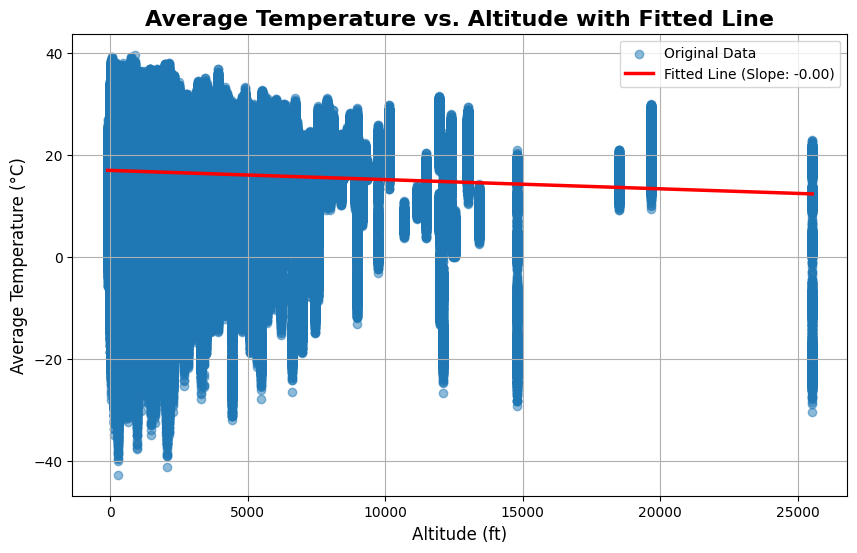

In [32]:
# Fit a linear model (polynomial of degree 1) to the data
slope, intercept = np.polyfit(new_dataset['Altitude (ft)'], new_dataset['AverageTemperature'], 1)

# Create the fitted line using the calculated slope and intercept
# We'll create a range of x-values from the minimum to maximum altitude
x_values = np.linspace(new_dataset['Altitude (ft)'].min(), new_dataset['Altitude (ft)'].max(), 100)
y_values_fitted = slope * x_values + intercept

# Plot the original data (you can use sampled data if preferred) and the fitted line
plt.figure(figsize=(10, 6))
plt.scatter(new_dataset['Altitude (ft)'], new_dataset['AverageTemperature'], alpha=0.5, label='Original Data') # Plot original data as scatter
plt.plot(x_values, y_values_fitted, color='red', linestyle='-', linewidth=2.5, label=f'Fitted Line (Slope: {slope:.2f})') # Plot the fitted line

# Add titles and labels
plt.title('Average Temperature vs. Altitude with Fitted Line', fontsize=16, fontweight='bold')
plt.xlabel('Altitude (ft)', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)

# Add grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.show()

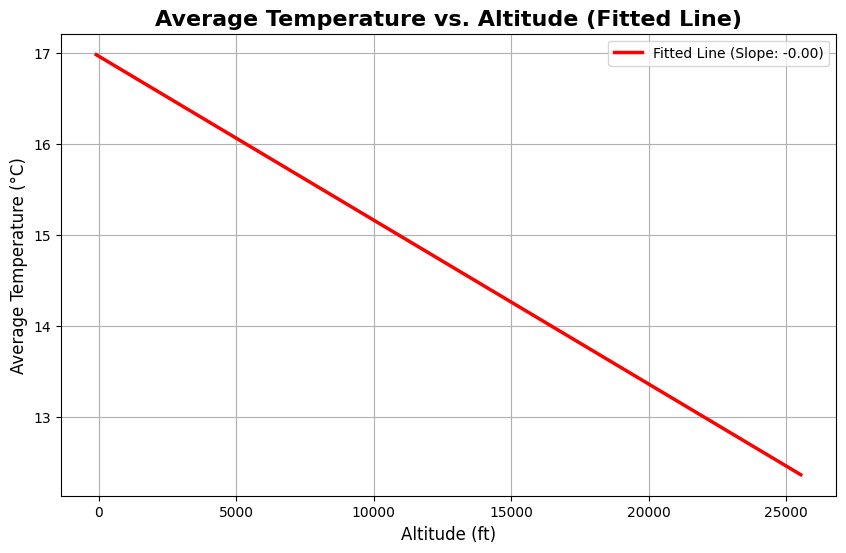

In [33]:
# Fit a linear model (polynomial of degree 1) to the data
slope, intercept = np.polyfit(new_dataset['Altitude (ft)'], new_dataset['AverageTemperature'], 1)

# Create the fitted line using the calculated slope and intercept
# We'll create a range of x-values from the minimum to maximum altitude
x_values = np.linspace(new_dataset['Altitude (ft)'].min(), new_dataset['Altitude (ft)'].max(), 100)
y_values_fitted = slope * x_values + intercept

# Plot only the fitted line
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values_fitted, color='red', linestyle='-', linewidth=2.5, label=f'Fitted Line (Slope: {slope:.2f})')

# Add titles and labels
plt.title('Average Temperature vs. Altitude (Fitted Line)', fontsize=16, fontweight='bold')
plt.xlabel('Altitude (ft)', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)

# Add grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.show()

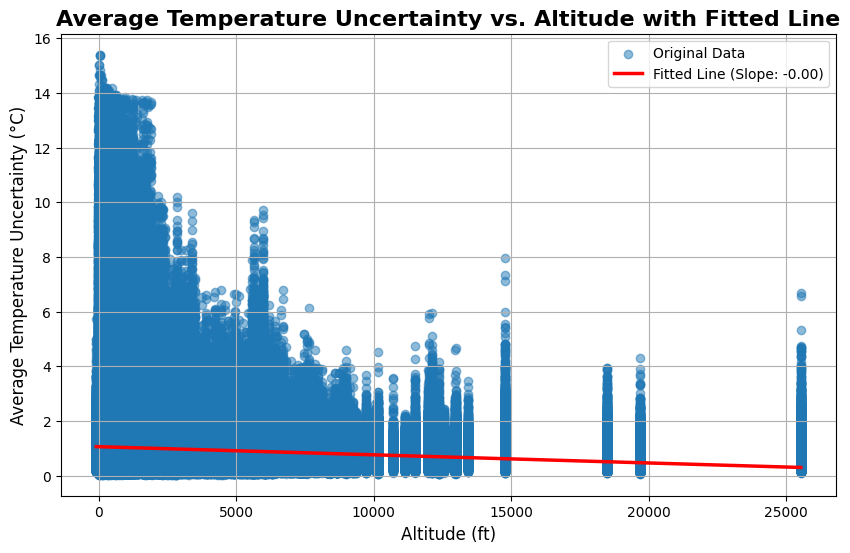

In [34]:
# Fit a linear model (polynomial of degree 1) to the data
slope, intercept = np.polyfit(new_dataset['Altitude (ft)'], new_dataset['AverageTemperatureUncertainty'], 1)

# Create the fitted line using the calculated slope and intercept
# We'll create a range of x-values from the minimum to maximum altitude
x_values = np.linspace(new_dataset['Altitude (ft)'].min(), new_dataset['Altitude (ft)'].max(), 100)
y_values_fitted = slope * x_values + intercept

# Plot the original data as a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(new_dataset['Altitude (ft)'], new_dataset['AverageTemperatureUncertainty'], alpha=0.5, label='Original Data')

# Plot the fitted line
plt.plot(x_values, y_values_fitted, color='red', linestyle='-', linewidth=2.5, label=f'Fitted Line (Slope: {slope:.2f})')

# Add titles and labels
plt.title('Average Temperature Uncertainty vs. Altitude with Fitted Line', fontsize=16, fontweight='bold')
plt.xlabel('Altitude (ft)', fontsize=12)
plt.ylabel('Average Temperature Uncertainty (°C)', fontsize=12)

# Add grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.show()

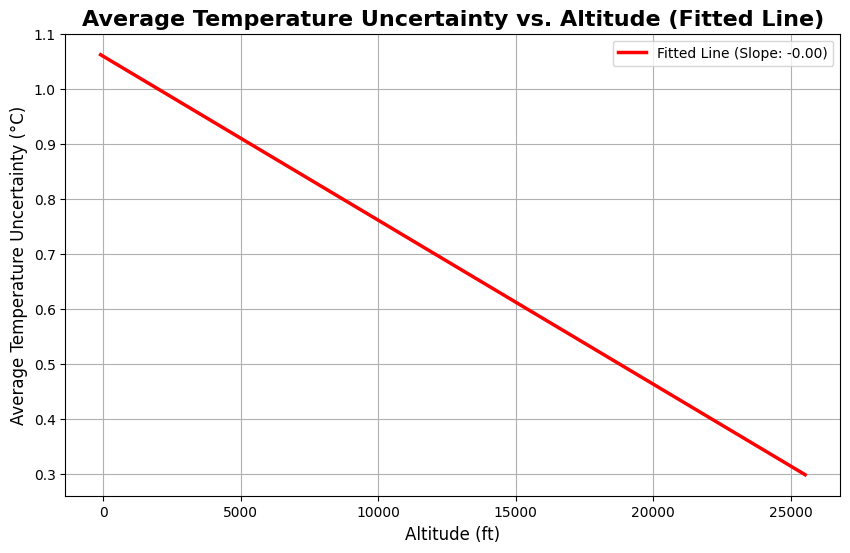

In [35]:
# Fit a linear model (polynomial of degree 1) to the data
slope, intercept = np.polyfit(new_dataset['Altitude (ft)'], new_dataset['AverageTemperatureUncertainty'], 1)

# Create the fitted line using the calculated slope and intercept
# We'll create a range of x-values from the minimum to maximum altitude
x_values = np.linspace(new_dataset['Altitude (ft)'].min(), new_dataset['Altitude (ft)'].max(), 100)
y_values_fitted = slope * x_values + intercept

# Plot only the fitted line
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values_fitted, color='red', linestyle='-', linewidth=2.5, label=f'Fitted Line (Slope: {slope:.2f})')

# Add titles and labels
plt.title('Average Temperature Uncertainty vs. Altitude (Fitted Line)', fontsize=16, fontweight='bold')
plt.xlabel('Altitude (ft)', fontsize=12)
plt.ylabel('Average Temperature Uncertainty (°C)', fontsize=12)

# Add grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.show()

# Finding the median of average temparature

# Replace with median

In [36]:
# Calculate the 80th percentile of the 'AverageTemperatureUncertainty' column
percentile_80_uncertainty = new_dataset['AverageTemperatureUncertainty'].quantile(0.80)
print(f"80th Percentile:",percentile_80_uncertainty)

# Replace values based on the comparison with the 80th percentile
new_dataset['AverageTemperatureUncertainty'] = (new_dataset['AverageTemperatureUncertainty'] >= percentile_80_uncertainty).astype(int)

# You can then display the first few rows to see the changes
print("New dataset with binary AverageTemperatureUncertainty:")
display(new_dataset.sample(10))

80th Percentile: 1.585
New dataset with binary AverageTemperatureUncertainty:


,dt,AverageTemperature,AverageTemperatureUncertainty,Altitude (ft),Latitude,Longitude
1988246,1988247,5.164,0,213.00000,44.20,22.36
1290190,1290191,25.823,0,0.00000,20.09,-71.66
3419240,3419241,16.529,0,16.00000,55.45,19.84
6638977,6635773,8.779,0,761.15500,45.81,-72.69
2765449,2765450,1.378,0,59.05510,40.99,-72.43
2308803,2308804,7.733,0,2588.58000,34.56,138.16
4553523,4551845,13.810,1,337.92700,34.56,-89.51
3248459,3248460,20.523,0,183.72700,36.17,-5.97
5198064,5194860,28.758,0,1197.51000,36.17,-97.46
8292062,9453696,12.385,0,800.52493,29.74,107.08


### Normalization

In [37]:
from sklearn.preprocessing import MinMaxScaler

# Identify the columns to normalize (all except 'AverageTemperatureUncertainty')
columns_to_normalize = new_dataset.columns.difference(['AverageTemperatureUncertainty'])

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Apply the scaler to the selected columns
new_dataset[columns_to_normalize] = scaler.fit_transform(new_dataset[columns_to_normalize])

# Display the first few rows of the normalized dataset
print("New dataset after normalization (excluding AverageTemperatureUncertainty):")
display(new_dataset.head())

New dataset after normalization (excluding AverageTemperatureUncertainty):


,dt,AverageTemperature,AverageTemperatureUncertainty,Altitude (ft),Latitude,Longitude
0,0.000000e+00,0.592217,1,0.003585,0.894646,0.492136
1,1.038627e-07,0.588817,1,0.003585,0.894646,0.492136
2,2.077254e-07,0.647781,0,0.003585,0.894646,0.492136
3,3.115882e-07,0.689151,0,0.003585,0.894646,0.492136
4,4.154509e-07,0.713812,0,0.003585,0.894646,0.492136


# Independent & Dependent features

In [ ]:
# new_dataset['Latitude']=new_dataset['Latitude']*2   # multiplying latitude with 3

In [ ]:
# new_dataset['Altitude (ft)']=new_dataset['Altitude (ft)']*2 # multiplying altitude with 3

In [38]:
display(new_dataset.head())

,dt,AverageTemperature,AverageTemperatureUncertainty,Altitude (ft),Latitude,Longitude
0,0.000000e+00,0.592217,1,0.003585,0.894646,0.492136
1,1.038627e-07,0.588817,1,0.003585,0.894646,0.492136
2,2.077254e-07,0.647781,0,0.003585,0.894646,0.492136
3,3.115882e-07,0.689151,0,0.003585,0.894646,0.492136
4,4.154509e-07,0.713812,0,0.003585,0.894646,0.492136


In [39]:
# Define the dependent variable (target)
y = new_dataset['AverageTemperatureUncertainty']

# Define the independent variables (features) by dropping the dependent variable
x = new_dataset.drop(columns=['AverageTemperatureUncertainty'])


# Display the first few rows of X and y to verify the split
print("Independent variables (X):")
display(x.head())

print("\nDependent variable (y):")
display(y.head())

Independent variables (X):


,dt,AverageTemperature,Altitude (ft),Latitude,Longitude
0,0.000000e+00,0.592217,0.003585,0.894646,0.492136
1,1.038627e-07,0.588817,0.003585,0.894646,0.492136
2,2.077254e-07,0.647781,0.003585,0.894646,0.492136
3,3.115882e-07,0.689151,0.003585,0.894646,0.492136
4,4.154509e-07,0.713812,0.003585,0.894646,0.492136



Dependent variable (y):


,AverageTemperatureUncertainty
0,1
1,1
2,0
3,0
4,0


# Train-Test Split

In [40]:
from pickle import FALSE
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,shuffle=False)

In [ ]:
# from sklearn.model_selection import train_test_split

# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [41]:
x_test.shape

(2116616, 5)

# Model Selection


# Decision Tree

In [42]:
# 1. Import the model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split # Import train_test_split

#taking 5 features


model = DecisionTreeClassifier(max_depth=10) # Added random_state for reproducibility

# 3. Train the model
model.fit(x_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(x_test)

# 5. Evaluate the model (Example using accuracy)
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# You can also print a classification report for more detailed metrics (precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7858827486894174

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88   1690587
           1       0.17      0.02      0.03    426029

    accuracy                           0.79   2116616
   macro avg       0.48      0.50      0.46   2116616
weighted avg       0.67      0.79      0.71   2116616



# Random Forest

In [43]:
# 1. Import the model
from sklearn.ensemble import RandomForestClassifier

#5 features

# 2. Create an instance of the model
# You can adjust parameters like n_estimators (number of trees) and random_state
# for reproducibility. We'll also set max_depth for the individual trees.
model = RandomForestClassifier(n_estimators=100, max_depth=10)

# 3. Train the model
model.fit(x_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(x_test)

# 5. Evaluate the model (Example using accuracy)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# You can also print a classification report for more detailed metrics (precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.7987216386911938

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89   1690587
           1       0.00      0.00      0.00    426029

    accuracy                           0.80   2116616
   macro avg       0.40      0.50      0.44   2116616
weighted avg       0.64      0.80      0.71   2116616



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# XGB

In [44]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report # Added classification_report for more detail [1]
import numpy as np # Import numpy

# Create an XGBoost model - keep it simple with a few basic settings
model = xgb.XGBClassifier(objective='binary:logistic',  # Good for yes/no answers
                          use_label_encoder=False,      # Avoids a message
                          eval_metric='logloss'       # How to measure performance
                          )              # Makes results consistent

# Train the model
# Convert y_train to a NumPy array
model.fit(x_train,np.array( y_train))

# Make predictions
y_pred = model.predict(x_test)

# Check the accuracy and get a report
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy}")

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:58:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7983413146267438

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89   1690587
           1       0.46      0.01      0.02    426029

    accuracy                           0.80   2116616
   macro avg       0.63      0.50      0.45   2116616
weighted avg       0.73      0.80      0.71   2116616



#  2 features only

In [ ]:
print("x_train shape:", x_train.shape)
print("y_train shape:", np.array(y_train).shape)


x_train shape: (6349846, 5)
y_train shape: (6349846,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 2 feature

# 1. Select the features: Create a new feature set with only the desired columns
x_selected_dt = new_dataset[['Altitude (ft)', 'AverageTemperature']]

# 2. Define dependent variable: y remains the same
y_dt = new_dataset['AverageTemperatureUncertainty']

# 3. Train-Test Split: Split the new feature set and target variable
x_train_dt, x_test_dt, y_train_dt, y_test_dt = train_test_split(x_selected_dt, y_dt, test_size=0.25, shuffle=False)

# 4. Apply Decision Tree: Create and train the model
# You can adjust parameters like max_depth or criterion
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

dt_model.fit(x_train_dt, y_train_dt)

# 5. Evaluate: Make predictions and evaluate the model
y_pred_dt = dt_model.predict(x_test_dt)

accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
print(f"Decision Tree Accuracy with selected features: {accuracy_dt}")

print("\nDecision Tree Classification Report with selected features:")
print(classification_report(y_test_dt, y_pred_dt))

Decision Tree Accuracy with selected features: 0.7984750186146188

Decision Tree Classification Report with selected features:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89   1690587
           1       0.40      0.00      0.00    426029

    accuracy                           0.80   2116616
   macro avg       0.60      0.50      0.45   2116616
weighted avg       0.72      0.80      0.71   2116616



# RF

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Select the features: Create a new feature set with only the desired columns
x_selected_rf = new_dataset[['Altitude (ft)', 'AverageTemperature']]

# 2. Define dependent variable: y remains the same
y_rf = new_dataset['AverageTemperatureUncertainty']

# 3. Train-Test Split: Split the new feature set and target variable
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(x_selected_rf, y_rf, test_size=0.25) # Using 0.25 test size

# 4. Apply Random Forest: Create and train the model
# You can adjust parameters like n_estimators (number of trees) and max_depth
rf_model_selected = RandomForestClassifier(n_estimators=100, max_depth=10)

rf_model_selected.fit(x_train_rf, y_train_rf)

# 5. Evaluate: Make predictions and evaluate the model
y_pred_rf = rf_model_selected.predict(x_test_rf)

accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
print(f"Random Forest Accuracy with selected features: {accuracy_rf}")

print("\nRandom Forest Classification Report with selected features:")
print(classification_report(y_test_rf, y_pred_rf))

Random Forest Accuracy with selected features: 0.8002155327182635

Random Forest Classification Report with selected features:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89   1693674
           1       0.61      0.00      0.00    422942

    accuracy                           0.80   2116616
   macro avg       0.71      0.50      0.44   2116616
weighted avg       0.76      0.80      0.71   2116616



# XGB

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 1. Select the features: Create a new feature set with only the desired columns
x_selected_xgb = new_dataset[['Altitude (ft)', 'AverageTemperature']]

# 2. Define dependent variable: y remains the same
y_xgb = new_dataset['AverageTemperatureUncertainty']

# 3. Train-Test Split: Split the new feature set and target variable
x_train_xgb, x_test_xgb, y_train_xgb, y_test_xgb = train_test_split(x_selected_xgb, y_xgb, test_size=0.25,shuffle=False) # Using 0.25 test size for consistency

# 4. Apply XGBoost: Create and train the model
# Use appropriate parameters for classification
xgb_model_selected = xgb.XGBClassifier(objective='binary:logistic',  # For binary classification
                                       use_label_encoder=False,      # To avoid a warning
                                       eval_metric='logloss'        # Evaluation metric
                                       )

xgb_model_selected.fit(x_train_xgb, y_train_xgb)

# 5. Evaluate: Make predictions and evaluate the model
y_pred_xgb = xgb_model_selected.predict(x_test_xgb)

accuracy_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
print(f"XGBoost Accuracy with selected features: {accuracy_xgb}")

print("\nXGBoost Classification Report with selected features:")
print(classification_report(y_test_xgb, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:16:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy with selected features: 0.7983743862845221

XGBoost Classification Report with selected features:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89   1690587
           1       0.40      0.00      0.01    426029

    accuracy                           0.80   2116616
   macro avg       0.60      0.50      0.45   2116616
weighted avg       0.72      0.80      0.71   2116616



# Applying PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # Keeping all 5 components

# Fit PCA on the training data and transform both training and test data
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

# Display the shape of the transformed data
print("Shape of original x_train:", x_train.shape)
print("Shape of x_train after PCA:", x_train_pca.shape)
print("\nShape of original x_test:", x_test.shape)
print("Shape of x_test after PCA:", x_test_pca.shape)


print("\nExplained variance ratio by each component:")
print(pca.explained_variance_ratio_)

# The sum of explained variance ratio shows the total variance retained
print("\nTotal explained variance ratio:", sum(pca.explained_variance_ratio_))

Shape of original x_train: (6349846, 5)
Shape of x_train after PCA: (6349846, 2)

Shape of original x_test: (2116616, 5)
Shape of x_test after PCA: (2116616, 2)

Explained variance ratio by each component:
[0.35037447 0.28517733]

Total explained variance ratio: 0.6355517933423023


# Decision Tree

In [ ]:
# 1. Import the model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split # Import train_test_split

#taking 5 features


model = DecisionTreeClassifier(max_depth=10) # Added random_state for reproducibility

# 3. Train the model
model.fit(x_train_pca, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(x_test_pca)

# 5. Evaluate the model (Example using accuracy)
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# You can also print a classification report for more detailed metrics (precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7945654762129739

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89   1690587
           1       0.21      0.01      0.01    426029

    accuracy                           0.79   2116616
   macro avg       0.50      0.50      0.45   2116616
weighted avg       0.68      0.79      0.71   2116616



In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report # Added classification_report for more detail [1]
import numpy as np # Import numpy

# Create an XGBoost model - keep it simple with a few basic settings
model = xgb.XGBClassifier(objective='binary:logistic',  # Good for yes/no answers
                          use_label_encoder=False,      # Avoids a message
                          eval_metric='logloss'       # How to measure performance
                          )              # Makes results consistent

# Train the model
# Convert y_train to a NumPy array
model.fit(x_train_pca,np.array( y_train))

# Make predictions
y_pred = model.predict(x_test_pca)

# Check the accuracy and get a report
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy}")

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:17:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7985888796078269

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89   1690587
           1       0.43      0.00      0.00    426029

    accuracy                           0.80   2116616
   macro avg       0.61      0.50      0.45   2116616
weighted avg       0.72      0.80      0.71   2116616



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 5 feature
# Create an instance of the KNN classifier (you can change n_neighbors)
knn = KNeighborsClassifier(n_neighbors=11)

# Train the model
knn.fit(x_train, y_train)

# Make predictions
y_pred_knn = knn.predict(x_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn}")

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.7967893089724353

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89   1690587
           1       0.31      0.01      0.02    426029

    accuracy                           0.80   2116616
   macro avg       0.55      0.50      0.45   2116616
weighted avg       0.70      0.80      0.71   2116616



# Getting Feature Importance

In [45]:
# Get feature importances from the trained Decision Tree model
feature_importances = model.feature_importances_

# Get the names of the features
feature_names = x_train.columns

# Create a pandas Series for better visualization
importance_series = pd.Series(feature_importances, index=feature_names)

# Sort the features by importance in descending order
sorted_importance_series = importance_series.sort_values(ascending=False)

# Display the feature importances
print("Feature Importances from Decision Tree Model (5 features):")
display(sorted_importance_series)

# Suggest a graph based on the most important features
most_important_feature = sorted_importance_series.index[0]
second_most_important_feature = sorted_importance_series.index[1]

print(f"\nThe most important feature is: {most_important_feature}")
print(f"The second most important feature is: {second_most_important_feature}")

print(f"\nBased on these importances, you could consider plotting 'AverageTemperatureUncertainty' against the most important feature ('{most_important_feature}').")
print(f"If you want to explore the relationship between the top two features, you could create a scatter plot of '{most_important_feature}' vs. '{second_most_important_feature}', potentially colored by 'AverageTemperatureUncertainty'.")

Feature Importances from Decision Tree Model (5 features):


,0
Latitude,0.664381
Longitude,0.169915
AverageTemperature,0.062488
Altitude (ft),0.055526
dt,0.047689



The most important feature is: Latitude
The second most important feature is: Longitude

Based on these importances, you could consider plotting 'AverageTemperatureUncertainty' against the most important feature ('Latitude').
If you want to explore the relationship between the top two features, you could create a scatter plot of 'Latitude' vs. 'Longitude', potentially colored by 'AverageTemperatureUncertainty'.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


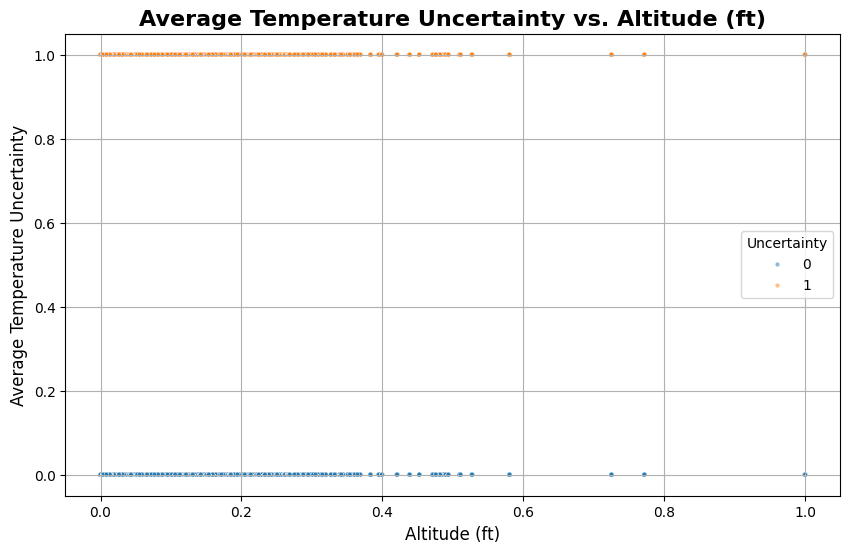

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of the most important feature ('Altitude (ft)') vs. the target variable ('AverageTemperatureUncertainty')
plt.figure(figsize=(10, 6))
sns.scatterplot(x=new_dataset['Altitude (ft)'], y=new_dataset['AverageTemperatureUncertainty'], hue=new_dataset['AverageTemperatureUncertainty'], alpha=0.5, s=10)

# Add titles and labels
plt.title('Average Temperature Uncertainty vs. Altitude (ft)', fontsize=16, fontweight='bold')
plt.xlabel('Altitude (ft)', fontsize=12)
plt.ylabel('Average Temperature Uncertainty', fontsize=12)

# Add grid and legend
plt.grid(True)
plt.legend(title='Uncertainty')

# Show plot
plt.show()